In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


from google.colab import drive
drive.mount('/content/drive')
from google.colab import files

Mounted at /content/drive


# Import data dari Drive

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/social_media_screentime_mental_health_2026.csv')

df

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,P306995,30,Male,Part-time employed,Europe,Snapchat,4,3.6,74,Never,...,4,4,6,3,10,2,Yes,No,No,Good
6996,P306996,28,Male,Self-employed,North America,Facebook,3,5.0,104,Every night,...,8,1,7,6,7,1,No,"Yes, failed",No,Moderate
6997,P306997,26,Prefer not to say,Unemployed,Oceania,LinkedIn,3,1.2,25,Never,...,9,4,5,1,6,3,No,No,No,Good
6998,P306998,22,Female,Student,Europe,Snapchat,4,3.6,182,Sometimes,...,5,7,4,1,6,2,No,"Yes, failed",No,Good


#Cek Struktur Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       7000 non-null   object 
 1   age                                  7000 non-null   int64  
 2   gender                               6930 non-null   object 
 3   occupation                           7000 non-null   object 
 4   region                               7000 non-null   object 
 5   most_used_platform                   7000 non-null   object 
 6   platforms_used_count                 7000 non-null   int64  
 7   daily_screen_hours                   7000 non-null   float64
 8   daily_notifications                  7000 non-null   int64  
 9   night_time_use                       7000 non-null   object 
 10  minutes_to_first_check_after_waking  7000 non-null   int64  
 11  primary_purpose               

In [4]:
df.columns

Index(['participant_id', 'age', 'gender', 'occupation', 'region',
       'most_used_platform', 'platforms_used_count', 'daily_screen_hours',
       'daily_notifications', 'night_time_use',
       'minutes_to_first_check_after_waking', 'primary_purpose',
       'avg_sleep_hours', 'anxiety_score_0to27', 'low_mood_score_0to27',
       'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10',
       'fomo_1to10', 'social_comparison_1to10',
       'physical_activity_days_per_week', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band'],
      dtype='object')

# Cek Quality Data

## Data Kosong

In [5]:
#cek data kosong

df.isnull().sum()

,0
participant_id,0
age,0
gender,70
occupation,0
region,0
most_used_platform,0
platforms_used_count,0
daily_screen_hours,0
daily_notifications,0
night_time_use,0


mengisi data kosong dengan modus

In [6]:
modus_gender = df['gender'].mode()[0]
df['gender'] = df['gender'].fillna(modus_gender)

modus_sleep_hours = df['avg_sleep_hours'].mode()[0]
df['avg_sleep_hours'] = df['avg_sleep_hours'].fillna(modus_sleep_hours)

## Data Duplikat

In [7]:
#cek data duplikat

df.duplicated().sum()

np.int64(0)

## Data Outlier


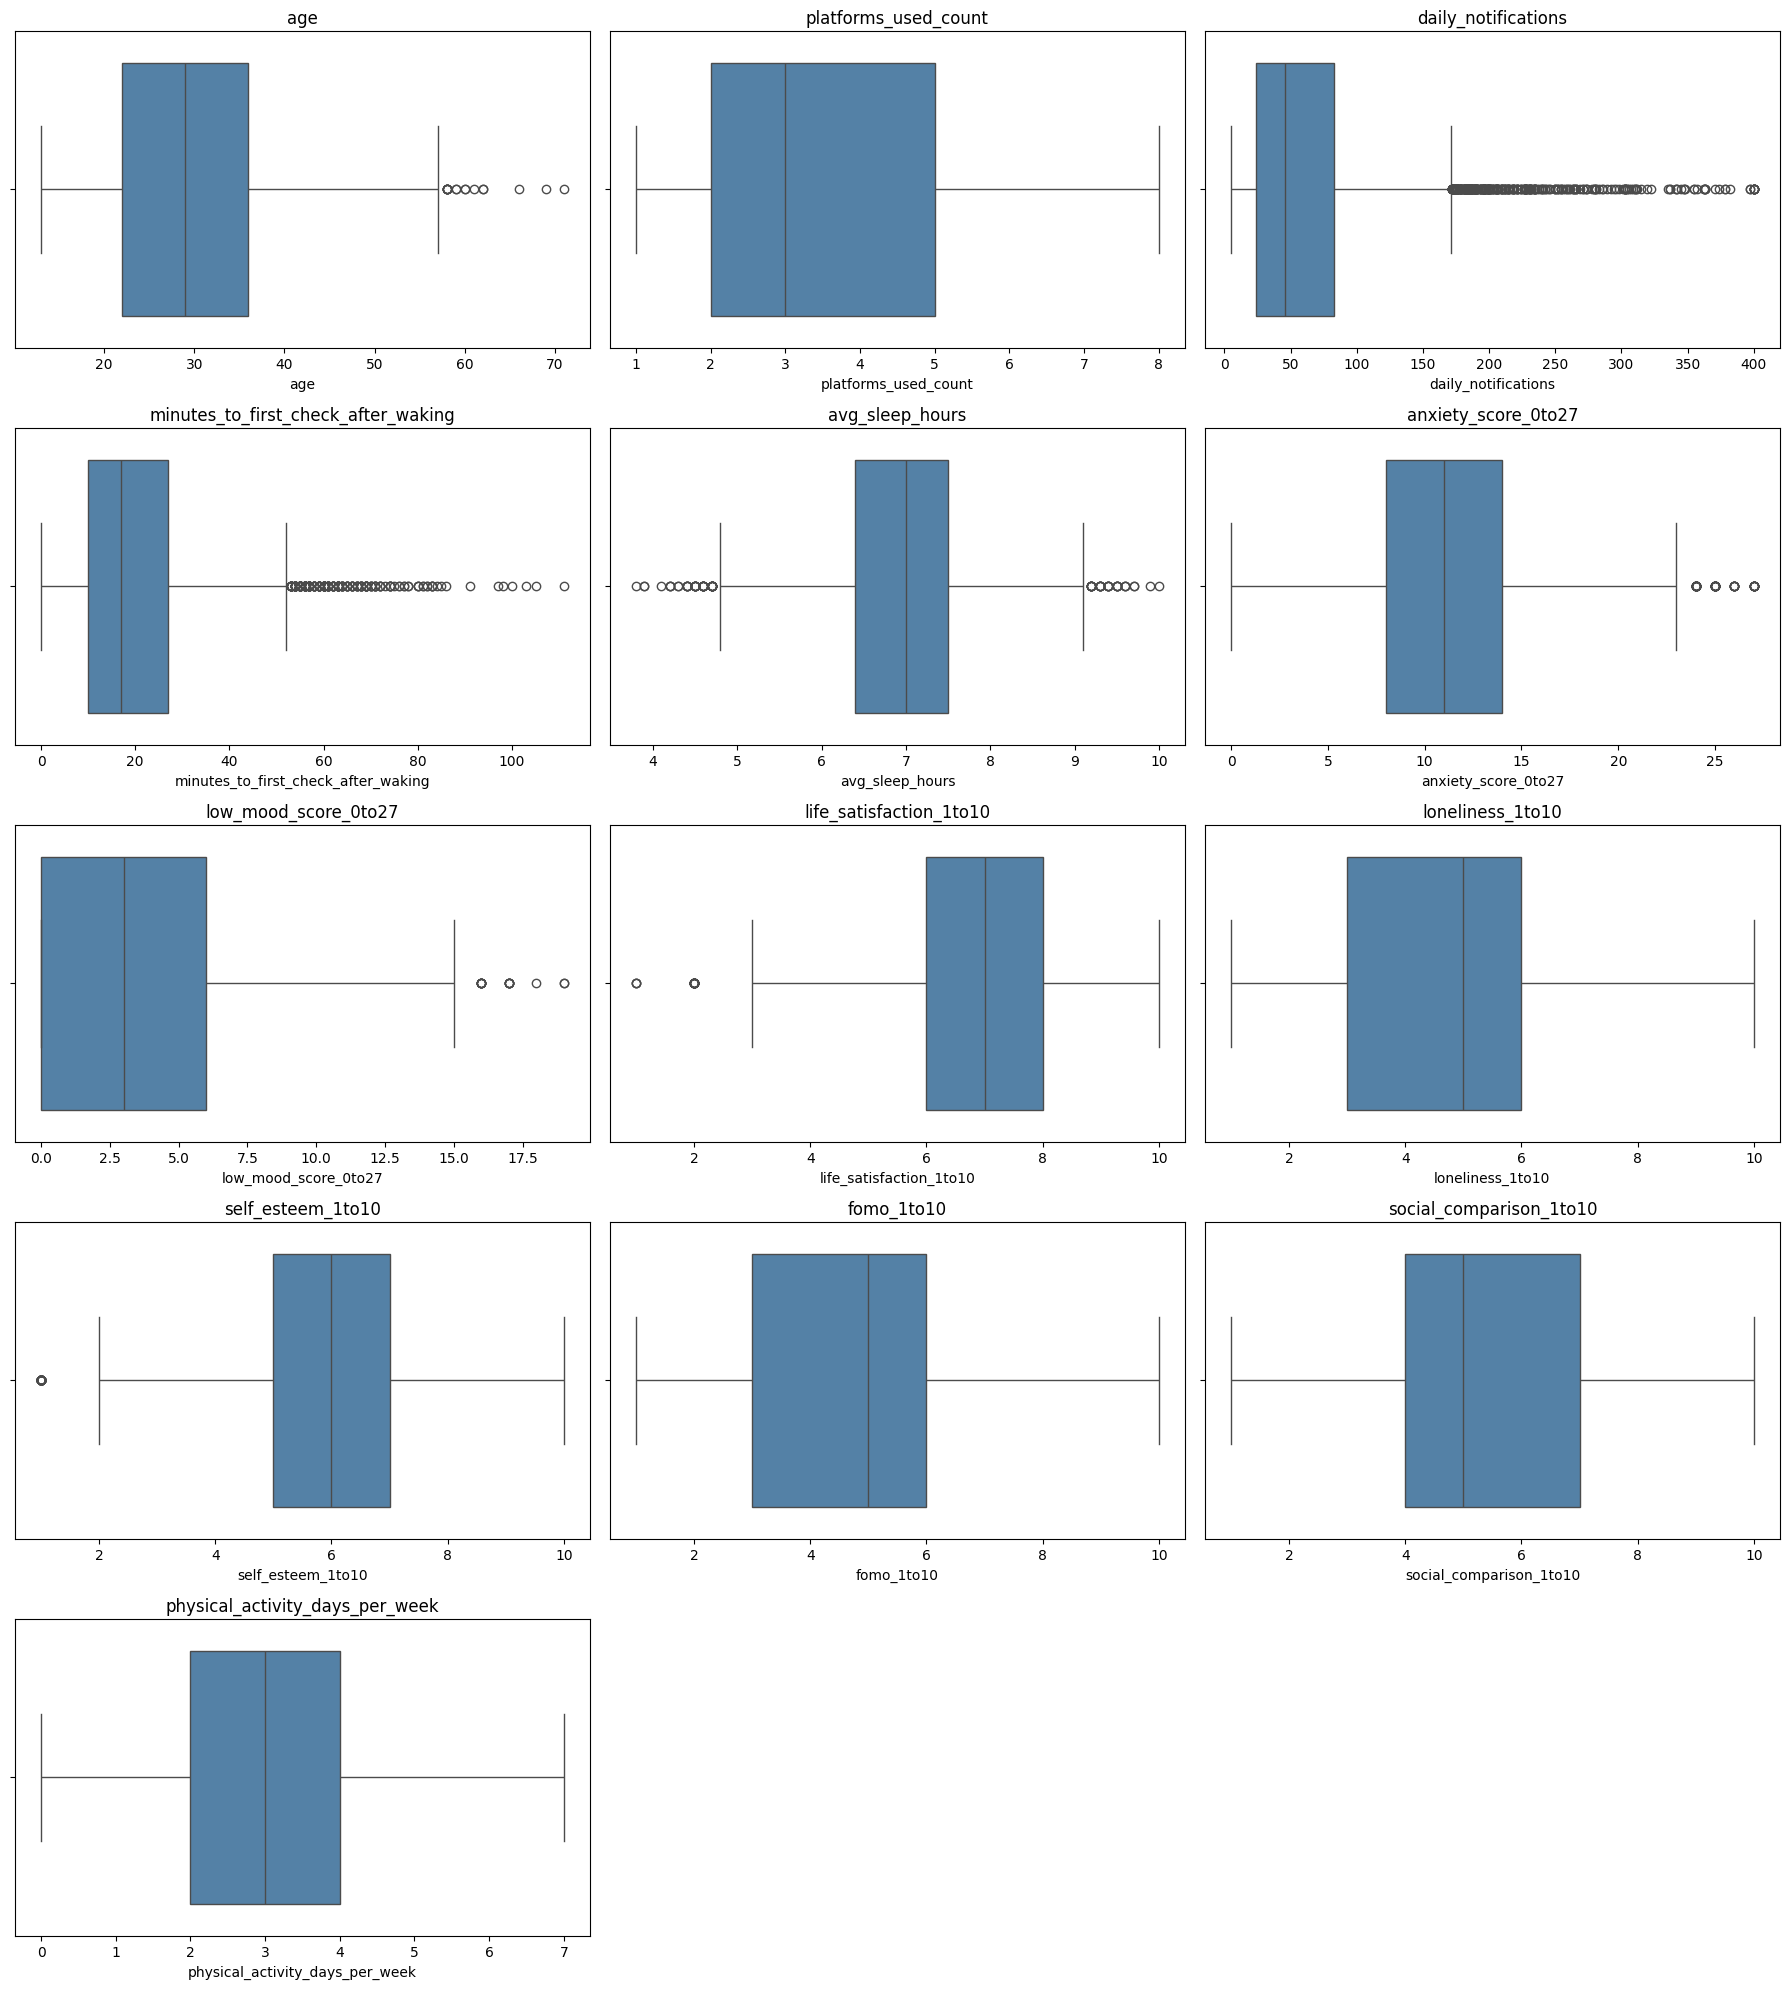

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
kolom_numerikal = [
    'age',
    'platforms_used_count',
    'daily_notifications',
    'minutes_to_first_check_after_waking',
    'avg_sleep_hours',
    'anxiety_score_0to27',
    'low_mood_score_0to27',
    'life_satisfaction_1to10',
    'loneliness_1to10',
    'self_esteem_1to10',
    'fomo_1to10',
    'social_comparison_1to10',
    'physical_activity_days_per_week'
]

fig,axes = plt.subplots(nrows = 5, ncols=3, figsize = (18,20))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerikal):
  sns.boxplot(data=df, x=kolom, ax=axes[i], color='steelblue')
  axes[i].set_title(kolom)

# Hide any unused subplots
for j in range(len(kolom_numerikal), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

files.download('boxplot.png')

## cek kesesuaian tipe data

In [9]:
df.dtypes

,0
participant_id,object
age,int64
gender,object
occupation,object
region,object
most_used_platform,object
platforms_used_count,int64
daily_screen_hours,float64
daily_notifications,int64
night_time_use,object


# Statistik Deskriptif

In [10]:
df.describe()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,29.246571,3.494571,3.304971,61.528286,20.008286,6.965514,11.378000,3.845714,6.955857,4.679286,6.006857,4.641857,5.323286,2.804143
std,9.569132,1.763637,1.881350,54.879070,13.976229,0.864031,4.777726,3.534197,1.614486,2.094803,1.886767,2.157439,2.090788,1.288418
min,13.000000,1.000000,0.200000,5.000000,0.000000,3.800000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,22.000000,2.000000,1.900000,24.000000,10.000000,6.400000,8.000000,0.000000,6.000000,3.000000,5.000000,3.000000,4.000000,2.000000
50%,29.000000,3.000000,3.000000,45.500000,17.000000,7.000000,11.000000,3.000000,7.000000,5.000000,6.000000,5.000000,5.000000,3.000000
75%,36.000000,5.000000,4.300000,83.000000,27.000000,7.500000,14.000000,6.000000,8.000000,6.000000,7.000000,6.000000,7.000000,4.000000
max,71.000000,8.000000,14.000000,400.000000,111.000000,10.000000,27.000000,19.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000


In [11]:
df.describe(include='object')

,participant_id,gender,occupation,region,most_used_platform,night_time_use,primary_purpose,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
count,7000,7000,7000,7000,7000,7000,7000,7000,7000,7000,7000
unique,7000,4,6,6,8,4,6,2,3,3,3
top,P306999,Male,Student,Asia,TikTok,Sometimes,Entertainment,No,No,No,Moderate
freq,1,3331,2715,1959,1733,2616,2147,4811,3509,4287,3766


In [12]:
df['gender'].mode()[0]

'Male'

In [13]:
df['avg_sleep_hours'].mode()

,avg_sleep_hours
0,7.0


# Analisis Univariate

## Numerikal

kolom_numerikal:
1. age
2. platforms_used_count
3. daily_notifications
4. minutes_to_first_check_after_waking
5. avg_sleep_hours
6. anxiety_score_0to27
7. low_mood_score_0to27
8. life_satisfaction_1to10
9. loneliness_1to10
10. self_esteem_1to10
11. fomo_1to10
12. social_comparison_1to10
13. physical_activity_days_per_week


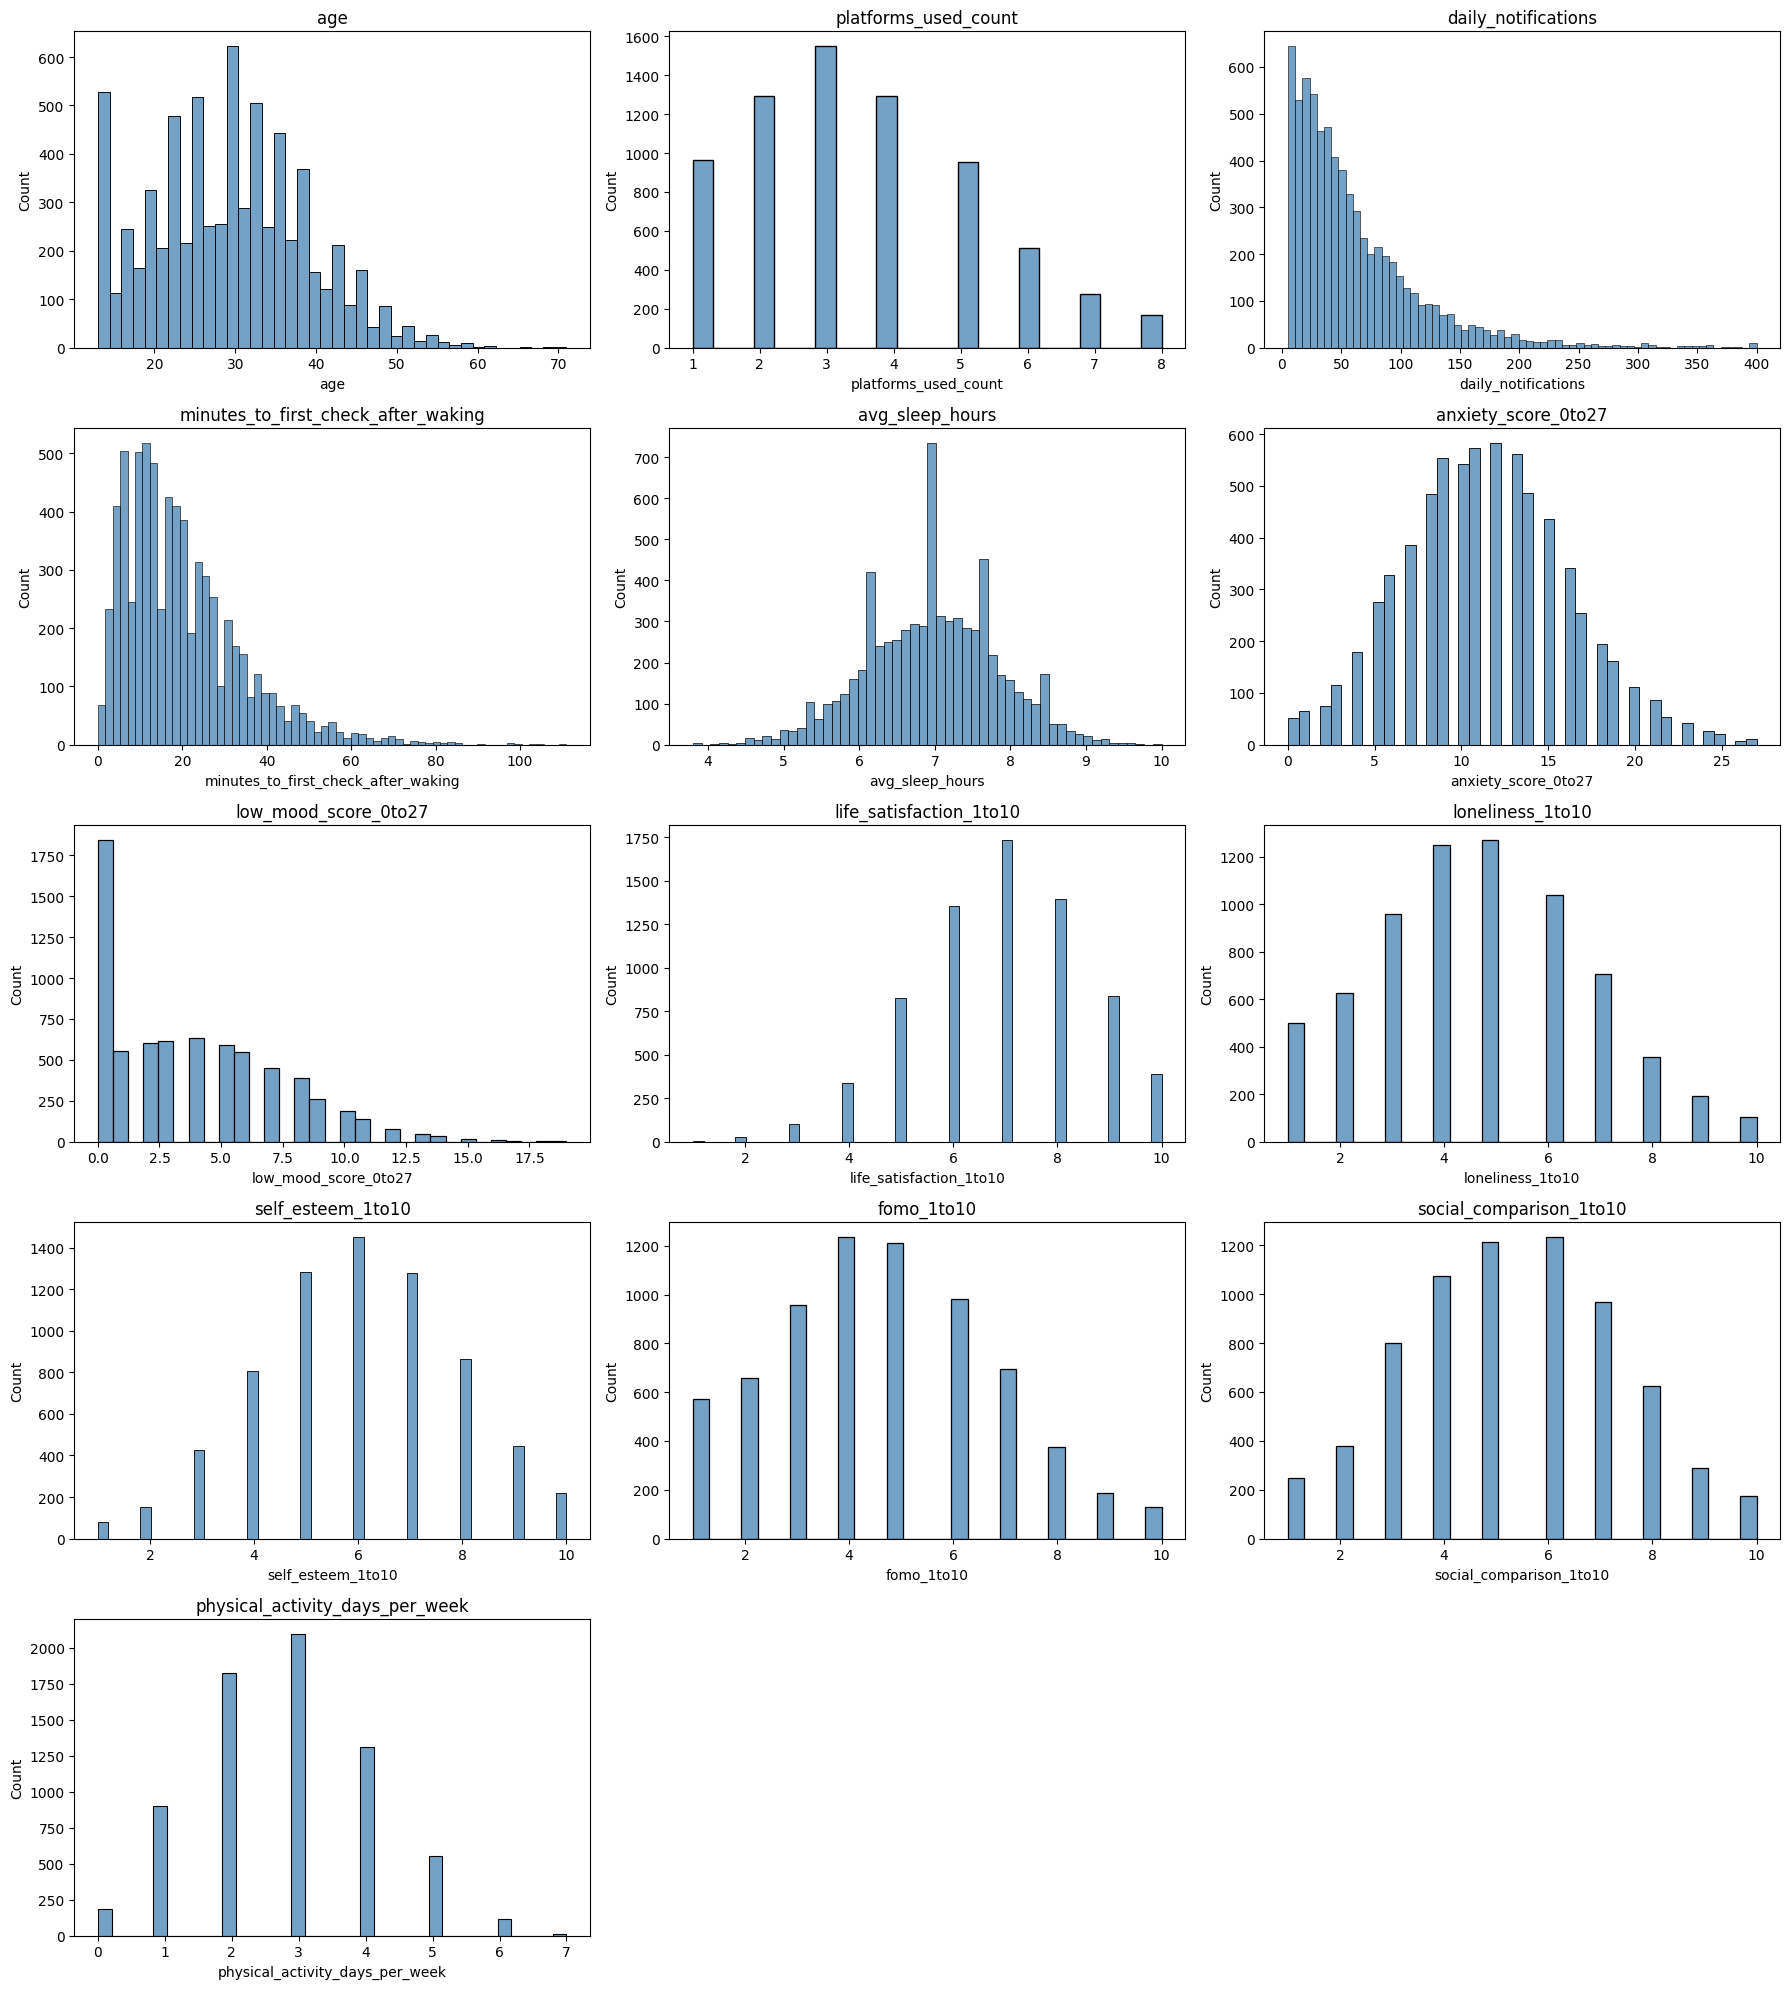

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:


kolom_numerikal = [
    'age',
    'platforms_used_count',
    'daily_notifications',
    'minutes_to_first_check_after_waking',
    'avg_sleep_hours',
    'anxiety_score_0to27',
    'low_mood_score_0to27',
    'life_satisfaction_1to10',
    'loneliness_1to10',
    'self_esteem_1to10',
    'fomo_1to10',
    'social_comparison_1to10',
    'physical_activity_days_per_week'
]

fig,axes = plt.subplots(nrows = 5, ncols=3, figsize = (18,20))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerikal):
  sns.histplot(data=df, x=kolom, kde=False, ax=axes[i], color='steelblue', edgecolor='black')
  axes[i].set_title(kolom)

# Hide any unused subplots
for j in range(len(kolom_numerikal), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('histogram.png', dpi=150, bbox_inches='tight')
plt.show()

files.download('histogram.png')



## Kategorikal

kolom_kategorikal:
1. participant_id
2. gender
3. occupation
4. region
5. most_used_platform
6. night_time_use
7. primary_purpose
8. uses_screen_time_limits
9.  attempted_digital_detox
10. seeks_mental_health_support
11. wellbeing_band

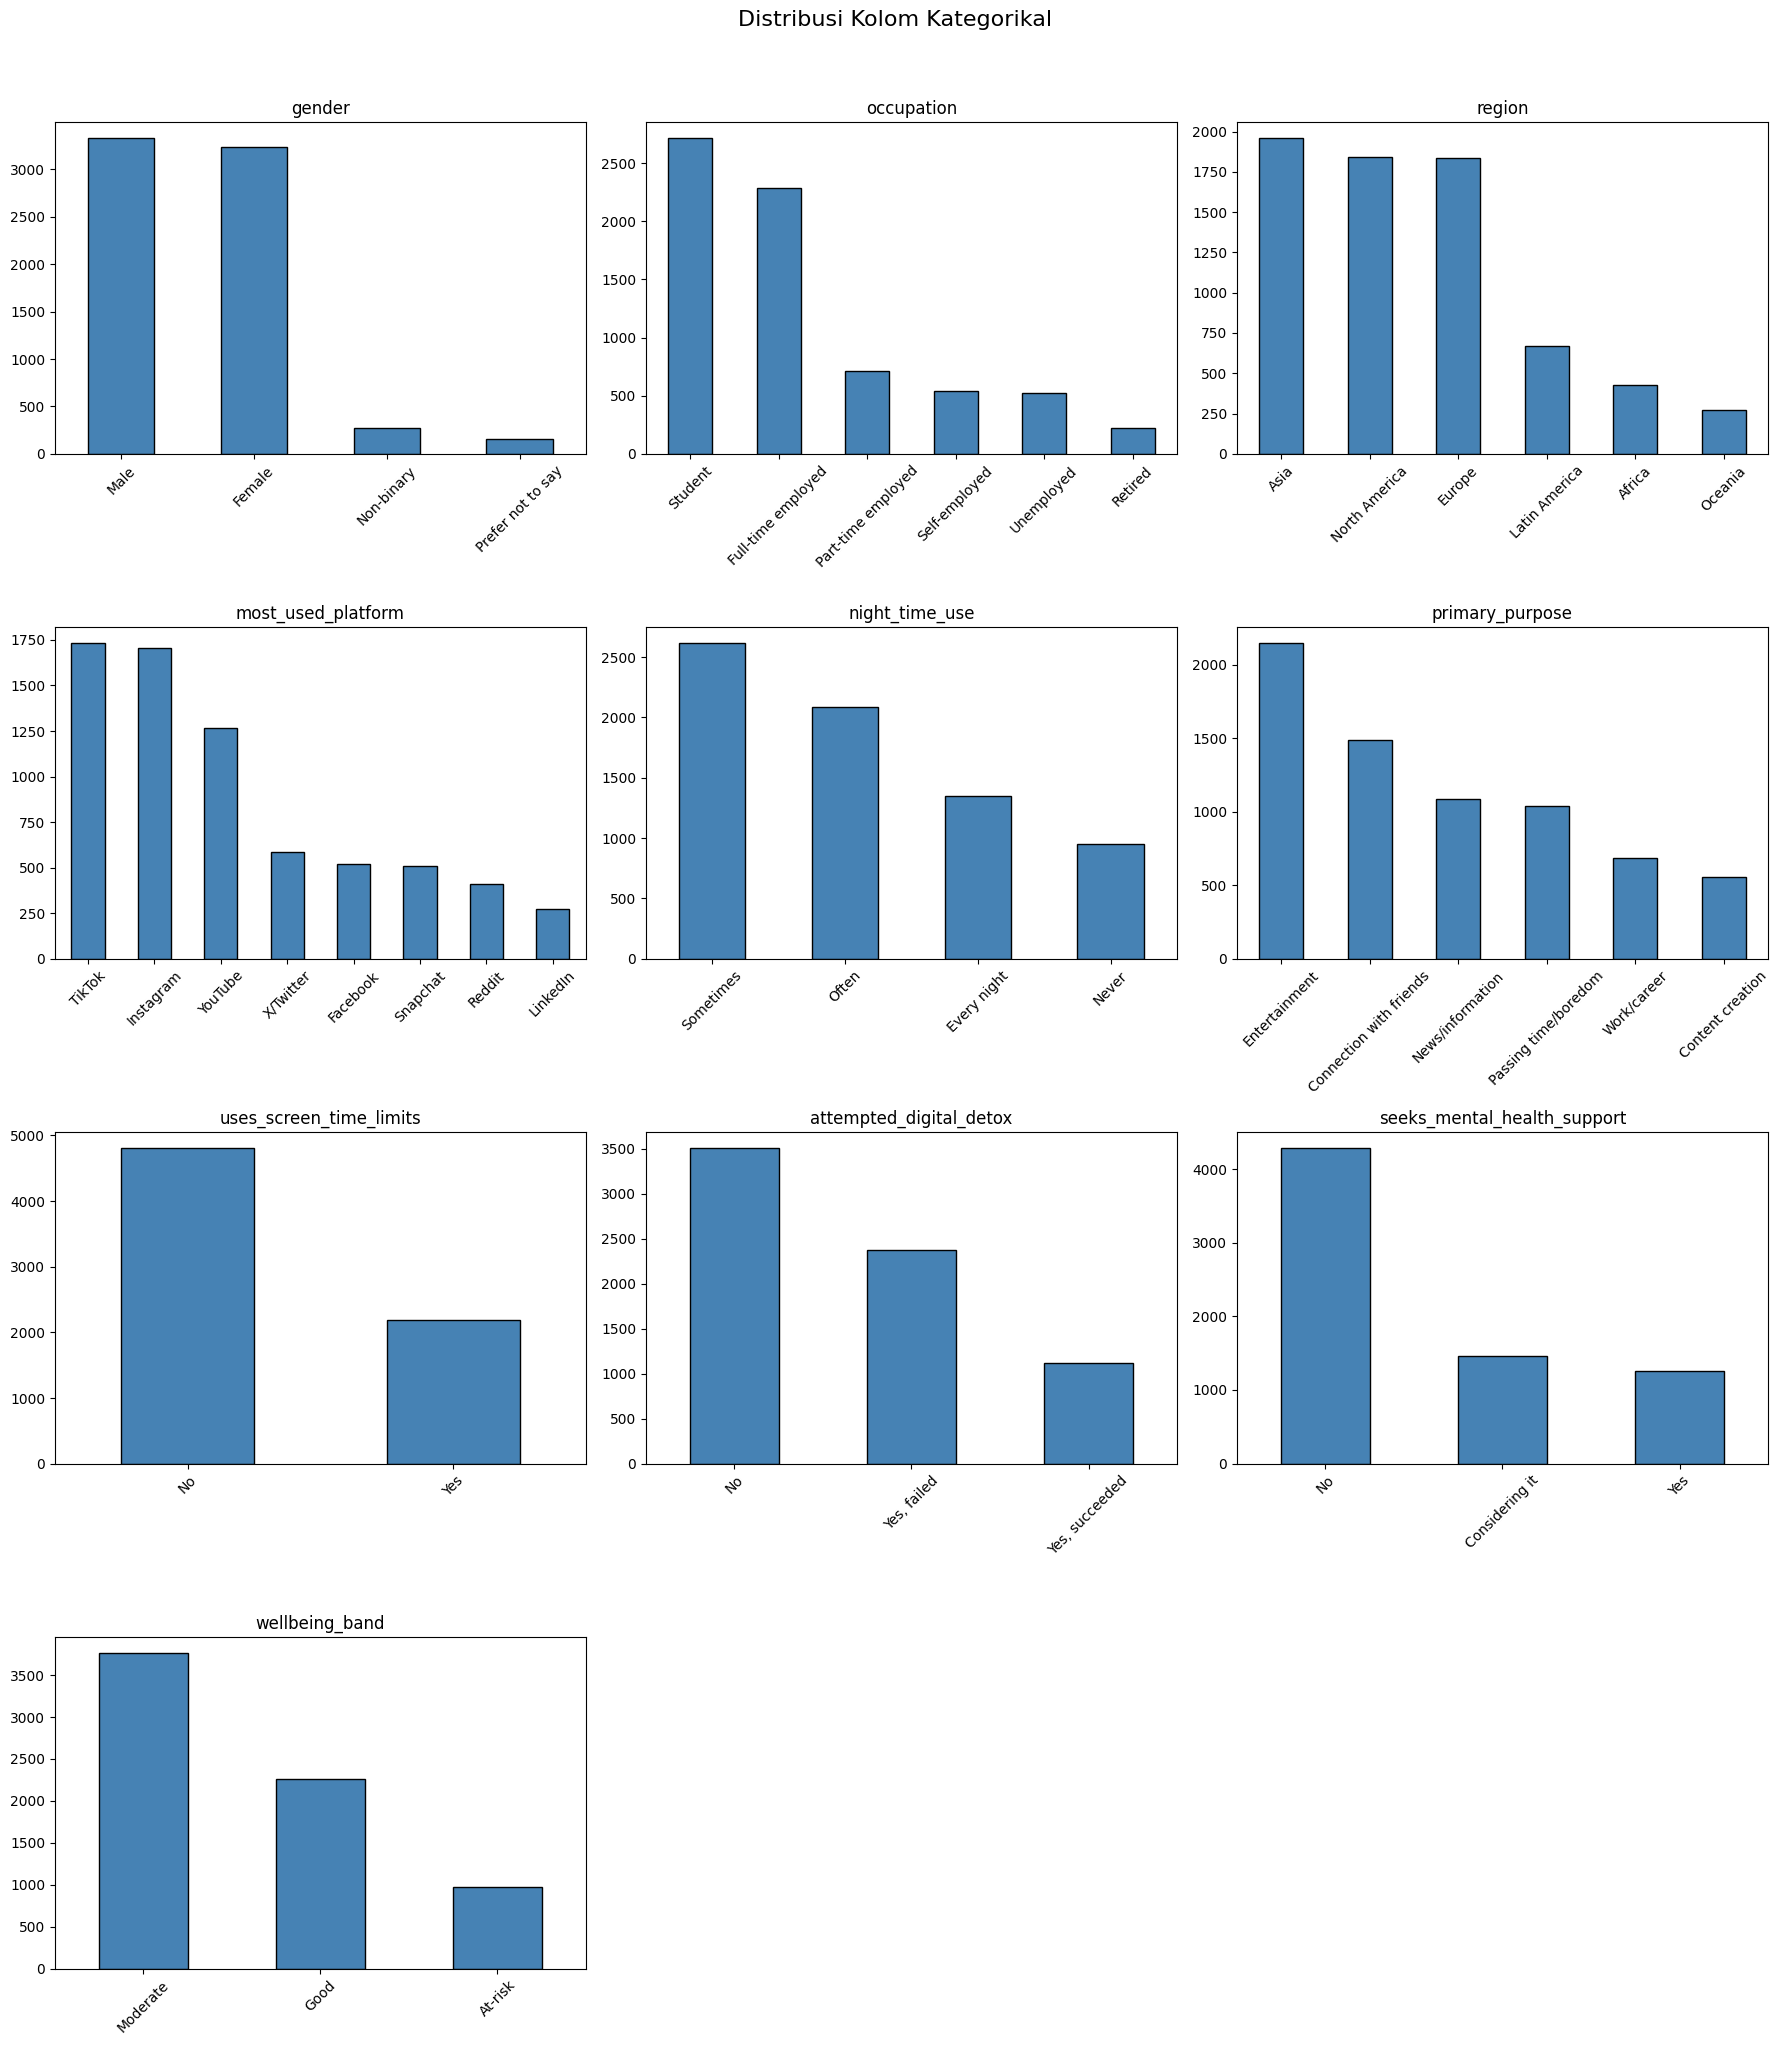

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
kolom_kategorikal = [
    'gender',
    'occupation',
    'region',
    'most_used_platform',
    'night_time_use',
    'primary_purpose',
    'uses_screen_time_limits',
    'attempted_digital_detox',
    'seeks_mental_health_support',
    'wellbeing_band'
]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()  # biar bisa diakses pakai index [0], [1], dst

for i, kolom in enumerate(kolom_kategorikal):
    df[kolom].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(kolom)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(len(kolom_kategorikal), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Kolom Kategorikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

files.download('bar_charts.png')

# Hypothesis Testing

## Numerikal & numerikal

Apakah Usia ada hubungannya sama aktivitas harian selama seminggu?

H0 = tidak ada hubungan antara age dengan aktivitas harian selama seminggu (korelasi = 0)
H1 = ada hubungan antara age dengan aktivitas harian selama seminggu
(korelasi = 1)


In [16]:
# melakukan tes distribusi

from scipy import stats

# Cek normalitas
stat_age, p_age = stats.shapiro(df['age'])
stat_activity, p_activity = stats.shapiro(df['physical_activity_days_per_week'])

print(f"Age normal? p-value: {p_age:.4f}")
print(f"Activity normal? p-value: {p_activity:.4f}")

Age normal? p-value: 0.0000
Activity normal? p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7000.
  res = hypotest_fun_out(*samples, **kwds)


In [17]:


corr, p_value = stats.spearmanr(df['age'], df['physical_activity_days_per_week'])

print(f"Korelasi Spearman: {corr:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Tolak H0 - ada hubungan signifikan antara usia dan aktivitas fisik")
else:
    print("Gagal tolak H0 - tidak cukup bukti ada hubungan")

Korelasi Spearman: -0.0184
p-value: 0.1232
Gagal tolak H0 - tidak cukup bukti ada hubungan


##Numerikal & kategorikal

Uji tes anova antara gender dengan anxiety score

In [18]:
from scipy import stats

groups = [df[df['gender'] == g]['anxiety_score_0to27'] for g in df['gender'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("✅ Ada perbedaan signifikan anxiety score antar gender")
else:
    print("❌ Tidak ada perbedaan signifikan")

F-statistic : 0.4616
P-value     : 0.7091
❌ Tidak ada perbedaan signifikan


/tmp/ipykernel_688/3521483484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='anxiety_score_0to27', palette='Set2')


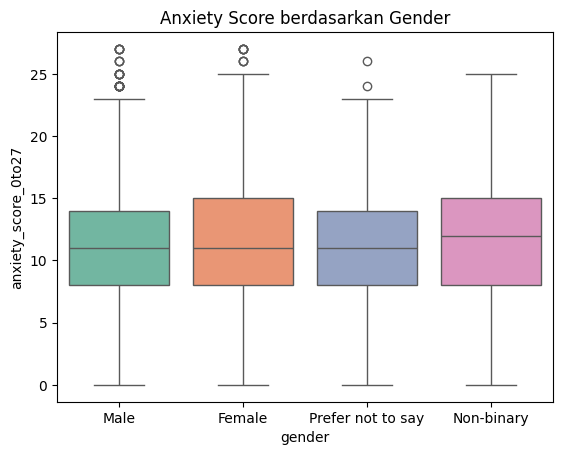

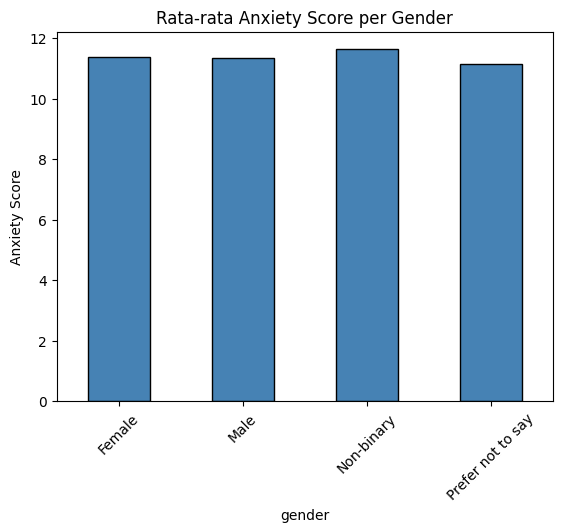

In [19]:


# Boxplot
sns.boxplot(data=df, x='gender', y='anxiety_score_0to27', palette='Set2')
plt.title('Anxiety Score berdasarkan Gender')
plt.show()

# Rata-rata per gender
df.groupby('gender')['anxiety_score_0to27'].mean().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rata-rata Anxiety Score per Gender')
plt.ylabel('Anxiety Score')
plt.xticks(rotation=45)
plt.show()

## Kategorikal & kategorikal

 Melakukan hypothesis testing apakah ada hubungan antara region dengan penggunaan limit screen time?

In [20]:
# 1 cek isi kedua kolom

print(df['region'].value_counts())
print(df['uses_screen_time_limits'].value_counts())

region
Asia             1959
North America    1842
Europe           1834
Latin America     670
Africa            425
Oceania           270
Name: count, dtype: int64
uses_screen_time_limits
No     4811
Yes    2189
Name: count, dtype: int64


In [21]:
# buat crosstab

crosstab = pd.crosstab(df['region'], df['uses_screen_time_limits'])
print(crosstab)

uses_screen_time_limits    No  Yes
region                            
Africa                    291  134
Asia                     1338  621
Europe                   1266  568
Latin America             475  195
North America            1252  590
Oceania                   189   81


In [22]:
# Chi Square Test

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(crosstab)

print(f"Chi2 statistic : {chi2:.4f}")
print(f"P-value        : {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("✅ Ada hubungan signifikan antara region dan uses_screen_time_limits")
else:
    print("❌ Tidak ada hubungan signifikan")

Chi2 statistic : 2.4183
P-value        : 0.7887
Degrees of freedom: 5
❌ Tidak ada hubungan signifikan


In [23]:
import numpy as np

n = crosstab.sum().sum()  # total data
min_dim = min(crosstab.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.0186


# Analisis Multivariate

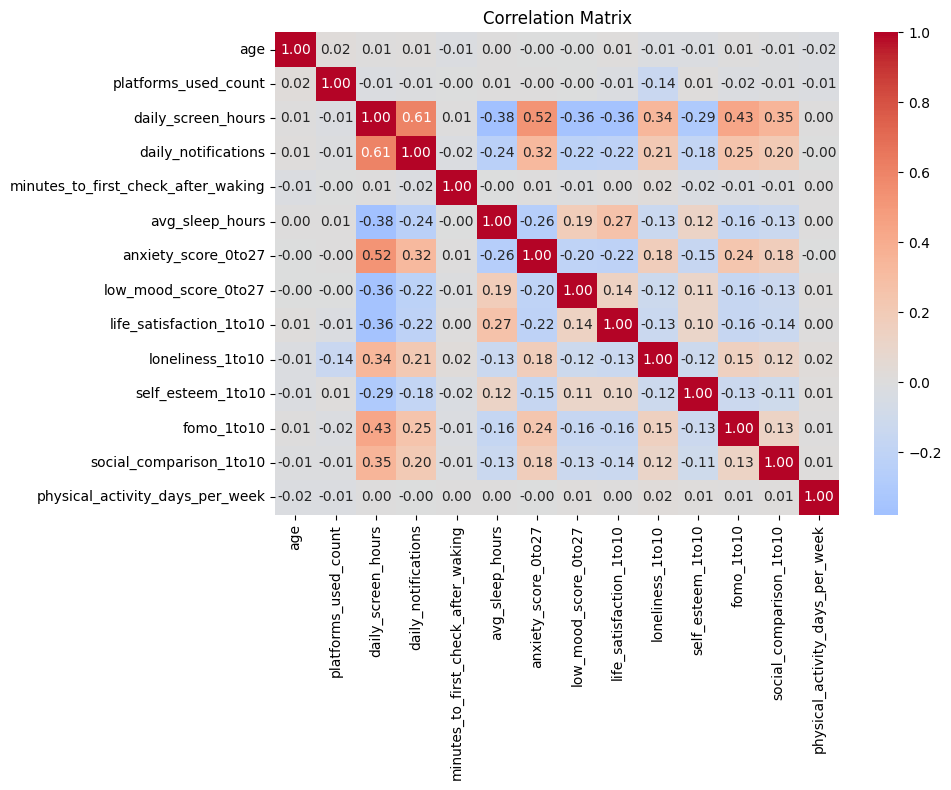

In [24]:


# Pilih kolom numerik saja
kolom_numerik = df.select_dtypes(include='number')

# Hitung korelasi
corr_matrix = kolom_numerik.corr()

# Visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,        # tampilkan angka korelasinya
            fmt='.2f',         # 2 desimal
            cmap='coolwarm',   # warna merah=positif, biru=negatif
            center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

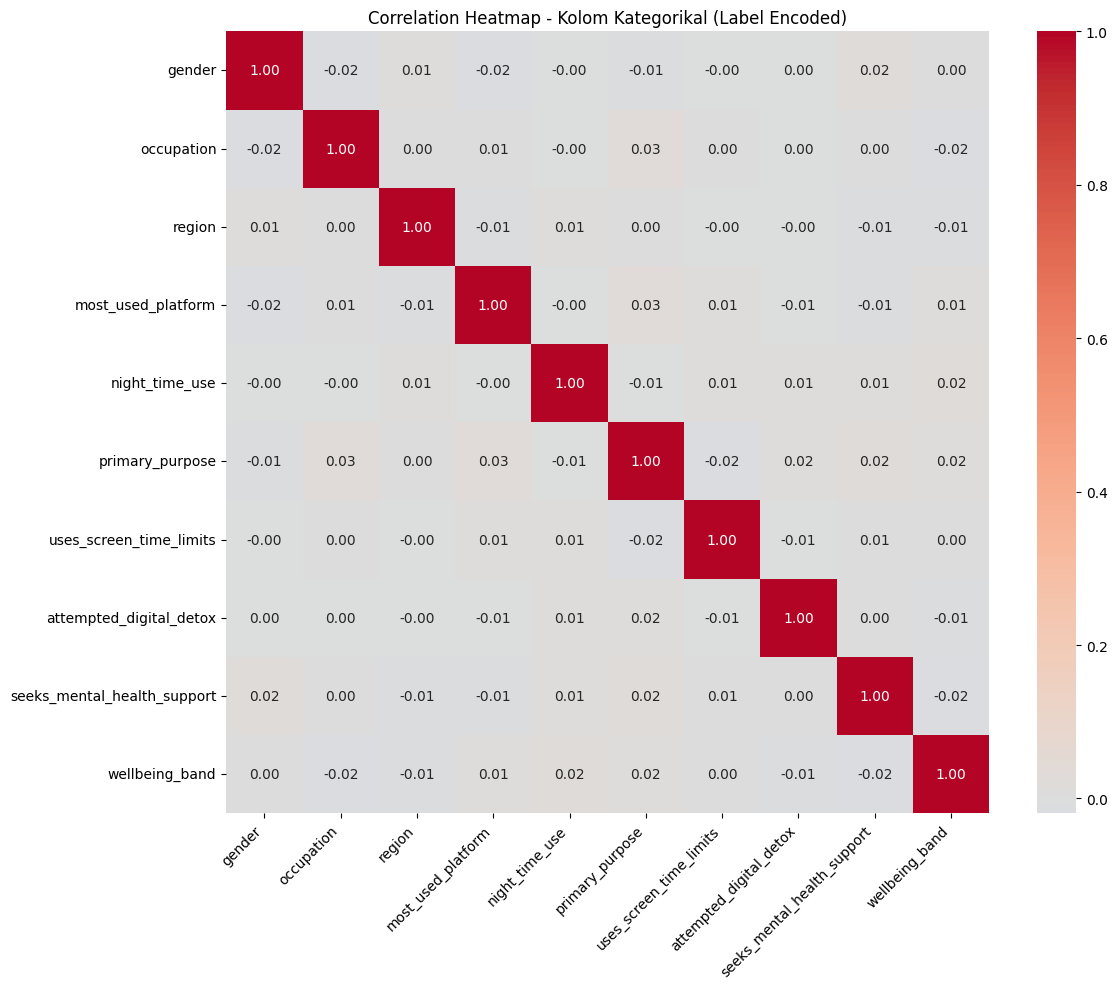

In [25]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df[kolom_kategorikal].copy()

le = LabelEncoder()
for col in kolom_kategorikal:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap - Kolom Kategorikal (Label Encoded)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analisis Bivariate

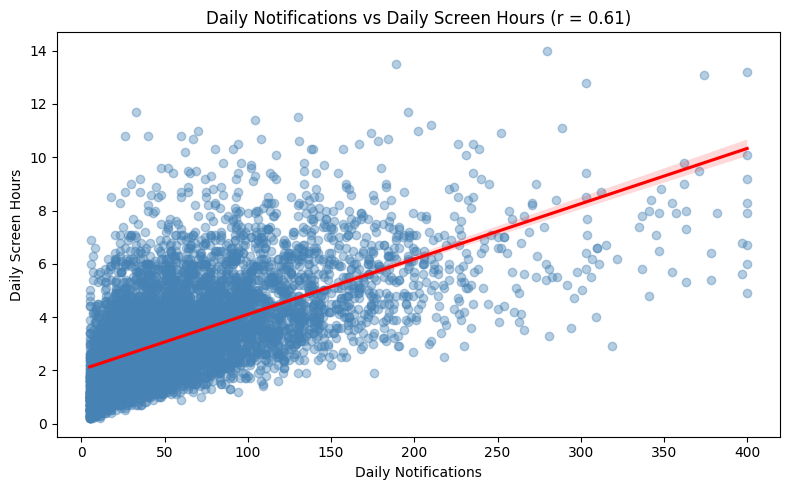

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.regplot(data=df,
            x='daily_notifications',
            y='daily_screen_hours',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'red'})
plt.title('Daily Notifications vs Daily Screen Hours (r = 0.61)')
plt.xlabel('Daily Notifications')
plt.ylabel('Daily Screen Hours')
plt.tight_layout()
plt.show()

In [27]:
from scipy import stats

# Cek normalitas dulu
stat1, p_norm1 = stats.shapiro(df['daily_notifications'].sample(500, random_state=42))
stat2, p_norm2 = stats.shapiro(df['daily_screen_hours'].sample(500, random_state=42))

print(f"Normalitas daily_notifications : p = {p_norm1:.4f}")
print(f"Normalitas daily_screen_hours  : p = {p_norm2:.4f}")

Normalitas daily_notifications : p = 0.0000
Normalitas daily_screen_hours  : p = 0.0000


Pada uji normalitas:
H0 = data berdistribusi normal
H1 = data tidak terdistribusi normal

Jadi aturan mainnya:

p-value < 0.05 (termasuk mendekati 0) → tolak H0 → artinya data TIDAK normal

p-value ≥ 0.05 → gagal tolak H0 → data (kemungkinan) normal

Jadi kalau p-value kamu 0, itu artinya datanya jauh dari normal, bukan normal.



In [28]:


# Kalau salah satu tidak normal → Spearman
r, p_value = stats.spearmanr(df['daily_notifications'], df['daily_screen_hours'])

print(f"Correlation : {r:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("✅ Korelasi signifikan secara statistik")
else:
    print("❌ Korelasi tidak signifikan")

Correlation : 0.6476
P-value     : 0.0000
✅ Korelasi signifikan secara statistik


# Persiapan Pembuatan Dashboard

## KPI

Daily Screen Hours

In [29]:
rata_rata = df['daily_screen_hours'].mean()
print(rata_rata)

3.304971428571429


In [39]:
# Normalisasi dulu ke skala 0-1 sebelum digabung
df['risk_score'] = (
    df['anxiety_score_0to27']/27*10 +
    df['low_mood_score_0to27']/27*10 +
    df['loneliness_1to10'] +
    df['fomo_1to10']
) / 4

#df['risk_score'] = (df['risk_score'] - df['risk_score'].min()) / (df['risk_score'].max() - df['risk_score'].min())

df['risk_score']

average_risk_score = df['risk_score'].mean()
print(average_risk_score)

3.7398888888888884


In [31]:
df['avg_wellbeing_score'] = (
    df['life_satisfaction_1to10'] + df['self_esteem_1to10']
) / 2

average_wellbeing_score = df['avg_wellbeing_score'].mean()
print(average_wellbeing_score)

6.481357142857143


## Line Chart

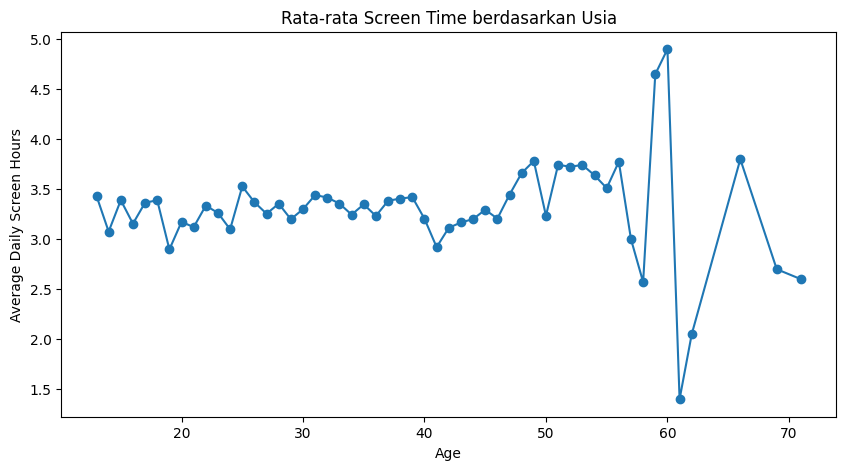

In [32]:
import matplotlib.pyplot as plt

age_screen = df.groupby('age')['daily_screen_hours'].mean()

plt.figure(figsize=(10,5))
plt.plot(age_screen.index, age_screen.values, marker='o')
plt.xlabel('Age')
plt.ylabel('Average Daily Screen Hours')
plt.title('Rata-rata Screen Time berdasarkan Usia')
plt.show()

## Pie Chart

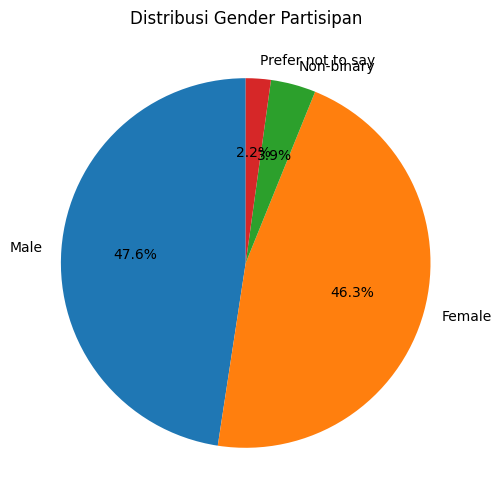

In [33]:
import matplotlib.pyplot as plt

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Gender Partisipan')
plt.show()

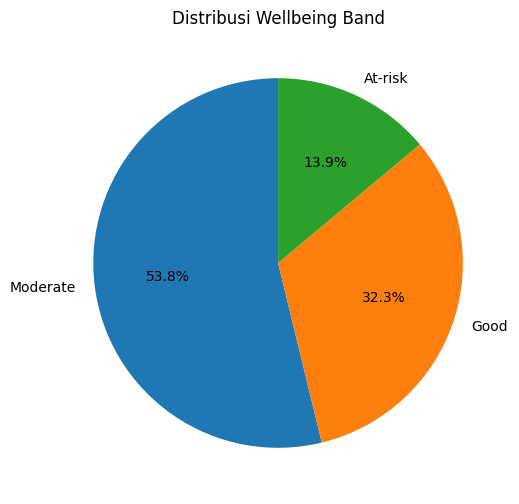

In [34]:
wellbeing_counts = df['wellbeing_band'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(wellbeing_counts, labels=wellbeing_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Wellbeing Band')
plt.show()

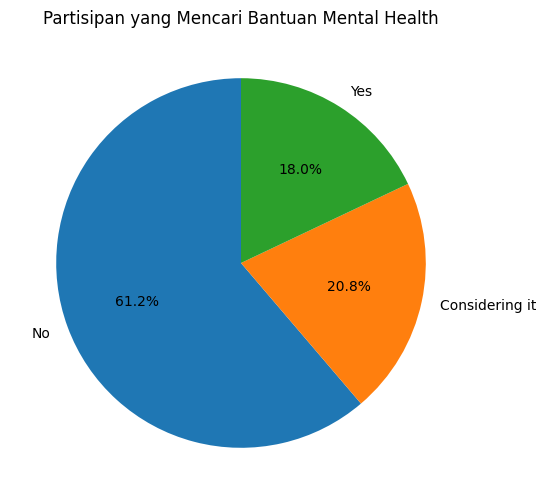

In [35]:
support_counts = df['seeks_mental_health_support'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(support_counts, labels=support_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Partisipan yang Mencari Bantuan Mental Health')
plt.show()

## Bar Chart

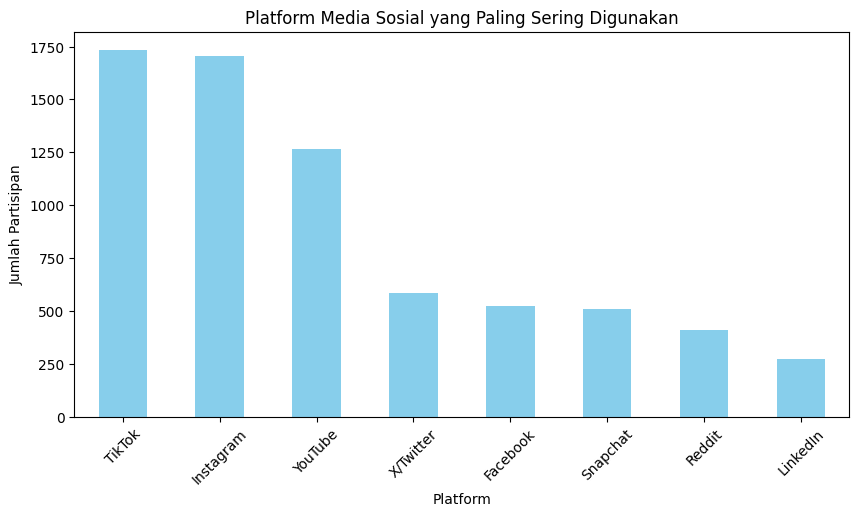

In [36]:
import matplotlib.pyplot as plt

platform_counts = df['most_used_platform'].value_counts()

plt.figure(figsize=(10,5))
platform_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Platform')
plt.ylabel('Jumlah Partisipan')
plt.title('Platform Media Sosial yang Paling Sering Digunakan')
plt.xticks(rotation=45)
plt.show()

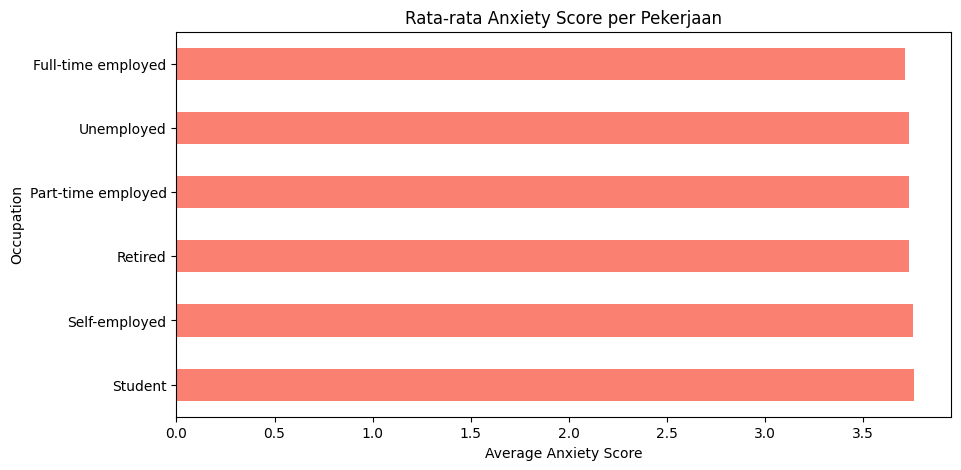

In [40]:
occ_anxiety = df.groupby('occupation')['risk_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
occ_anxiety.plot(kind='barh', color='salmon')
plt.xlabel('Average Anxiety Score')
plt.ylabel('Occupation')
plt.title('Rata-rata Anxiety Score per Pekerjaan')
plt.show()

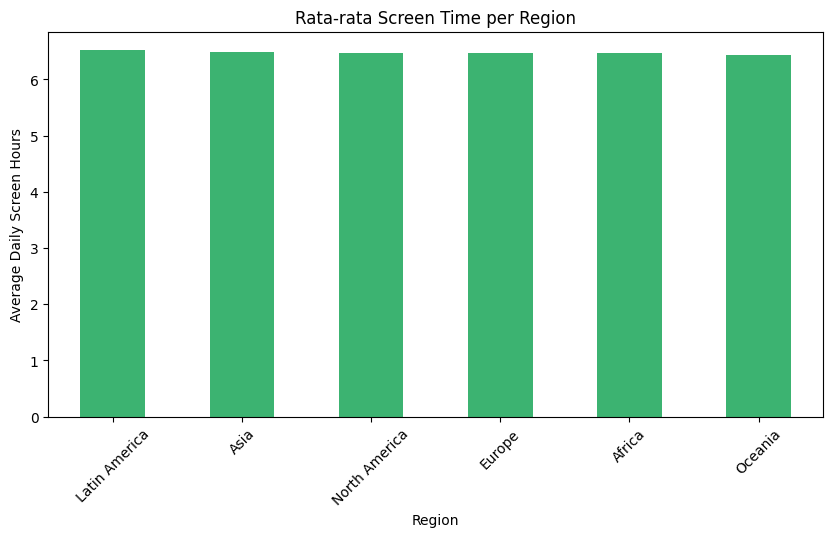

In [41]:
region_screen = df.groupby('region')['avg_wellbeing_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_screen.plot(kind='bar', color='mediumseagreen')
plt.xlabel('Region')
plt.ylabel('Average Daily Screen Hours')
plt.title('Rata-rata Screen Time per Region')
plt.xticks(rotation=45)
plt.show()

# Kesimpulan Analisis

## Insight

Berikut adalah 3 insight paling penting dari seluruh analisis yang telah dilakukan:

1. Korelasi Kuat antara Notifikasi Harian dan Durasi Layar Harian: Terdapat hubungan positif yang signifikan secara statistik antara jumlah notifikasi harian yang diterima dan durasi layar harian (korelasi Spearman = 0.6476, p-value < 0.0000). Hal ini menunjukkan bahwa semakin banyak notifikasi yang diterima, semakin tinggi pula durasi penggunaan layar, atau sebaliknya.

2. Tidak Ada Perbedaan Signifikan pada Skor Kecemasan Berdasarkan Gender dan Tidak Ada Hubungan Usia dengan Aktivitas Fisik: Hasil uji hipotesis menunjukkan bahwa tidak ada perbedaan yang signifikan dalam skor kecemasan antar gender (p-value = 0.7091) dan tidak ada hubungan signifikan antara usia dengan jumlah hari aktivitas fisik per minggu (p-value = 0.1232). Ini mengindikasikan bahwa faktor-faktor ini mungkin tidak menjadi penentu utama dari variabel tersebut dalam dataset ini.

3. Platform Dominan dan Status Kesejahteraan (Wellbeing): TikTok, Instagram, dan YouTube adalah platform media sosial yang paling sering digunakan oleh partisipan. Mayoritas partisipan berada dalam kategori 'Moderate' untuk wellbeing band (53.8%), diikuti oleh 'Good' (32.3%) dan 'At-risk' (13.9%), menunjukkan bahwa sebagian besar pengguna memiliki tingkat kesejahteraan menengah, namun ada juga proporsi yang perlu diperhatikan berada dalam risiko.

## Rekomendasi

Berikut adalah 3 rekomendasi berdasarkan insight yang telah ditemukan:

1.  **Promosi Pengelolaan Notifikasi Digital**: Mengingat korelasi kuat antara notifikasi harian dan durasi layar, edukasi dan alat untuk mengelola notifikasi (misalnya, mematikan notifikasi yang tidak penting, menjadwalkan waktu 'bebas notifikasi') dapat membantu pengguna mengurangi waktu layar yang tidak disengaja dan meningkatkan fokus.
2.  **Fokus pada Intervensi Kesehatan Mental yang Lebih Personal**: Karena skor kecemasan tidak menunjukkan perbedaan signifikan berdasarkan gender dan usia tidak berkorelasi dengan aktivitas fisik, program intervensi kesehatan mental sebaiknya didesain agar lebih personal dan tidak hanya berdasar pada demografi luas. Fokus dapat diarahkan pada faktor-faktor lain yang ditemukan berkorelasi dengan kesejahteraan mental.
3.  **Pengembangan Konten dan Fitur Kesejahteraan pada Platform Dominan**: Dengan TikTok, Instagram, dan YouTube sebagai platform paling sering digunakan, ada peluang besar untuk bekerja sama dengan platform-platform ini dalam mengembangkan fitur-fitur yang mendukung kesejahteraan pengguna. Ini bisa berupa alat deteksi dini risiko mental, kampanye kesadaran, atau bahkan fitur yang membatasi penggunaan berlebihan, terutama bagi mereka yang berada di kategori 'At-risk'.